In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt



# Load data


In [4]:
# Load data
df = pd.read_csv("sample_data/global_climate_energy_2020_2024.csv")


In [5]:
TARGET_COL = "energy_consumption"
df.head()

,date,country,avg_temperature,humidity,co2_emission,energy_consumption,renewable_share,urban_population,industrial_activity_index,energy_price
0,2020-01-01,Germany,28.29,31.08,212.63,11348.75,14.42,76.39,51.22,83.93
1,2020-01-02,Germany,28.38,37.94,606.05,4166.64,5.63,86.26,78.27,110.40
2,2020-01-03,Germany,28.74,57.67,268.72,4503.80,14.20,75.92,48.96,173.58
3,2020-01-04,Germany,26.66,51.34,167.32,3259.13,13.84,63.15,97.42,89.13
4,2020-01-05,Germany,26.81,65.38,393.89,7023.72,6.93,76.02,81.89,40.60


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic statistics:")
print(df.describe())


Missing values:
date                         0
country                      0
avg_temperature              0
humidity                     0
co2_emission                 0
energy_consumption           0
renewable_share              0
urban_population             0
industrial_activity_index    0
energy_price                 0
dtype: int64

Basic statistics:
       avg_temperature      humidity  co2_emission  energy_consumption  \
count     36540.000000  36540.000000  36540.000000        36540.000000   
mean         13.580868     59.971469    445.820452         7295.904857   
std          10.077249     17.303103    234.360906         3693.928504   
min          -9.600000     30.000000     50.150000         1001.890000   
25%           5.630000     45.010000    248.675000         4184.177500   
50%          13.790000     59.990000    422.655000         6921.620000   
75%          20.840000     74.970000    628.422500        10175.110000   
max          38.710000     90.000000    999.85000

In [8]:
print("\n" + "="*60)
print("PREPROCESSING")
print("="*60)

# Drop rows with missing values
df = df.dropna()
print(f"Dataset shape after removing NaN: {df.shape}")

# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target from numerical columns
if TARGET_COL in numerical_cols:
    numerical_cols.remove(TARGET_COL)

print(f"\nCategorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

# For this dataset: date is date, country is categorical
# Keep date info but encode country
print(f"\nBefore encoding:")
print(f"  - date: {df['date'].dtype}")
print(f"  - country: unique values = {df['country'].nunique()}")



PREPROCESSING
Dataset shape after removing NaN: (36540, 10)

Categorical columns: ['date', 'country']
Numerical columns: ['avg_temperature', 'humidity', 'co2_emission', 'renewable_share', 'urban_population', 'industrial_activity_index', 'energy_price']

Before encoding:
  - date: object
  - country: unique values = 20


In [9]:
# Convert date to datetime and extract features
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek
df['quarter'] = df['date'].dt.quarter

print("\nExtracted date features:")
print(f"  - year, month, day, dayofweek, quarter")

# Drop the original date column (no longer needed)
df = df.drop(columns=['date'])

# One-hot encode 'country' (categorical variable)
df_encoded = pd.get_dummies(df, columns=['country'], drop_first=True)

print(f"\nAfter one-hot encoding country:")
print(f"  - New shape: {df_encoded.shape}")
print(f"  - New columns: {df_encoded.columns.tolist()}")


Extracted date features:
  - year, month, day, dayofweek, quarter

After one-hot encoding country:
  - New shape: (36540, 32)
  - New columns: ['avg_temperature', 'humidity', 'co2_emission', 'energy_consumption', 'renewable_share', 'urban_population', 'industrial_activity_index', 'energy_price', 'year', 'month', 'day', 'dayofweek', 'quarter', 'country_Brazil', 'country_Canada', 'country_China', 'country_France', 'country_Germany', 'country_India', 'country_Indonesia', 'country_Italy', 'country_Japan', 'country_Mexico', 'country_Netherlands', 'country_Norway', 'country_Poland', 'country_South Africa', 'country_Spain', 'country_Sweden', 'country_Turkey', 'country_United Kingdom', 'country_United States']


# Standarization

In [10]:
# ============================================
# CELL 4: STANDARDIZATION
# ============================================

print("\n" + "="*60)
print("STANDARDIZATION")
print("="*60)

# Separate features and target
X = df_encoded.drop(columns=[TARGET_COL])
y = df_encoded[[TARGET_COL]].copy()

print(f"Features shape before scaling: {X.shape}")
print(f"Target shape: {y.shape}")

# Standardize features
feature_scaler = StandardScaler()
X_scaled = feature_scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Standardize target
target_scaler = StandardScaler()
y_scaled = target_scaler.fit_transform(y)
y_scaled = pd.Series(y_scaled.flatten(), name=TARGET_COL)

print("\nFeatures standardized (mean ≈ 0, std ≈ 1)")
print("\nFeature statistics after standardization:")
print(X_scaled.describe())
print("\nTarget statistics after standardization:")
print(y_scaled.describe())



STANDARDIZATION
Features shape before scaling: (36540, 31)
Target shape: (36540, 1)

Features standardized (mean ≈ 0, std ≈ 1)

Feature statistics after standardization:
       avg_temperature      humidity  co2_emission  renewable_share  \
count     3.654000e+04  3.654000e+04  3.654000e+04     3.654000e+04   
mean      2.800168e-17 -2.866284e-16  1.687879e-16     3.437985e-16   
std       1.000014e+00  1.000014e+00  1.000014e+00     1.000014e+00   
min      -2.300349e+00 -1.732168e+00 -1.688319e+00    -2.051477e+00   
25%      -7.890027e-01 -8.646816e-01 -8.412160e-01    -7.355722e-01   
50%       2.075322e-02  1.070990e-03 -9.884656e-02    -4.294118e-02   
75%       7.203585e-01  8.668235e-01  7.791596e-01     7.302937e-01   
max       2.493684e+00  1.735466e+00  2.364034e+00     2.797877e+00   

       urban_population  industrial_activity_index  energy_price  \
count      3.654000e+04               3.654000e+04  3.654000e+04   
mean      -1.071648e-15               5.355322e-16 -1

In [11]:
print("data set after preprocessing:")
print(X_scaled.head())
print(y_scaled.head())

data set after preprocessing:
   avg_temperature  humidity  co2_emission  renewable_share  urban_population  \
0         1.459658 -1.669751     -0.995019        -0.285690          0.162845   
1         1.468589 -1.273284      0.683697        -1.933383          1.304509   
2         1.504313 -0.133011     -0.755684        -0.326929          0.108480   
3         1.297905 -0.498846     -1.188356        -0.394412         -1.368626   
4         1.312790  0.312580     -0.221586        -1.689697          0.120047   

   industrial_activity_index  energy_price     year     month       day  ...  \
0                  -1.093369     -0.637481 -1.41344 -1.600676 -1.673987  ...   
1                   0.467096     -0.099229 -1.41344 -1.600676 -1.560381  ...   
2                  -1.223744      1.185500 -1.41344 -1.600676 -1.446776  ...   
3                   1.571824     -0.531742 -1.41344 -1.600676 -1.333170  ...   
4                   0.675927     -1.518572 -1.41344 -1.600676 -1.219565  ...   

  

In [12]:
#split data into train and test sets and validation set
print("\n" + "="*60)
print("DATA SPLITTING")
print("="*60)

X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")


DATA SPLITTING
Training set: 21924 samples
Validation set: 7308 samples
Test set: 7308 samples
Number of features: 31


In [13]:
# poly = PolynomialFeatures(degree=2, include_bias=False)  # Changed from 3 to 2

# X_train_poly = poly.fit_transform(X_train)
# X_val_poly = poly.transform(X_val)
# X_test_poly = poly.transform(X_test)

# X_train = pd.DataFrame(X_train_poly)
# X_val = pd.DataFrame(X_val_poly)
# X_test = pd.DataFrame(X_test_poly)

# print(f"Features after polynomial (degree=2): {X_train.shape[1]}")

In [14]:
print("\n" + "="*60)
print("CONVERTING TO PYTORCH TENSORS")
print("="*60)

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print(f"X_train tensor shape: {X_train_tensor.shape}")
print(f"y_train tensor shape: {y_train_tensor.shape}")
print(f"X_val tensor shape: {X_val_tensor.shape}")
print(f"X_test tensor shape: {X_test_tensor.shape}")

print("\n" + "="*60)
print("PREPROCESSING COMPLETE!")
print("="*60)
print(f"Ready for model training with {X_train.shape[1]} features")


CONVERTING TO PYTORCH TENSORS
X_train tensor shape: torch.Size([21924, 31])
y_train tensor shape: torch.Size([21924, 1])
X_val tensor shape: torch.Size([7308, 31])
X_test tensor shape: torch.Size([7308, 31])

PREPROCESSING COMPLETE!
Ready for model training with 31 features


In [23]:
class EBM(nn.Module):
    """EBM with Softmax output layer for energy prediction"""

    def __init__(self, input_dim, hidden_dim=512, dropout_rate=0.05, num_outputs=10):
        super(EBM, self).__init__()

        # Feature extraction layers
        self.features = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.BatchNorm1d(hidden_dim // 4),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
        )

        # Output layer with Softmax (for probability distribution)
        self.softmax_layer = nn.Linear(hidden_dim // 4, num_outputs)
        self.softmax = nn.Softmax(dim=1)

        # Energy bins - map softmax probabilities to energy values
        # This creates a discrete energy landscape
        self.register_buffer('energy_bins', torch.linspace(0, 1, num_outputs))
        self.num_outputs = num_outputs

    def forward(self, x):
        features = self.features(x)
        logits = self.softmax_layer(features)
        probabilities = self.softmax(logits)

        # Expected energy value (weighted sum of bins)
        energy_pred = torch.sum(probabilities * self.energy_bins.unsqueeze(0), dim=1, keepdim=True)

        return energy_pred, probabilities, logits

In [25]:
input_dim = X_train.shape[1]
num_bins = 20  # Number of energy bins for softmax

model = EBM(input_dim, hidden_dim=512, dropout_rate=0.05, num_outputs=num_bins)

# Best loss function for softmax + energy regression
criterion_softmax = nn.CrossEntropyLoss()  # For softmax probabilities
criterion_regression = nn.MSELoss()  # For final regression

# Best optimizer and learning rate
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=0.0001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)

# Best hyperparameters found
num_epochs = 1000
batch_size = 32
patience = 200
best_val_loss = float('inf')
patience_counter = 0

train_losses = []
val_losses = []


EBM WITH SOFTMAX - OPTIMIZED FOR ENERGY CONSUMPTION PREDICTION


In [26]:
# ============================================
# TRAINING LOOP WITH SOFTMAX
# ============================================

for epoch in range(num_epochs):
    model.train()

    permutation = torch.randperm(X_train_tensor.size(0))
    epoch_loss = 0.0
    num_batches = 0

    for i in range(0, X_train_tensor.size(0), batch_size):
        indices = permutation[i:i+batch_size]
        batch_X = X_train_tensor[indices]
        batch_y = y_train_tensor[indices]

        # Forward pass through softmax
        energy_pred, probabilities, logits = model(batch_X)

        # Create targets for softmax (bin indices based on normalized y values)
        # Normalize y to [0, 1] and map to bin indices
        y_normalized = (batch_y - y_train_tensor.min()) / (y_train_tensor.max() - y_train_tensor.min())
        y_bins = torch.clamp((y_normalized * (num_bins - 1)).long(), 0, num_bins - 1)

        # Combined loss: softmax classification + regression
        loss_softmax = criterion_softmax(logits, y_bins.squeeze())
        loss_regression = criterion_regression(energy_pred, batch_y)

        # Total loss (weighted combination)
        loss = 0.3 * loss_softmax + 0.7 * loss_regression

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    avg_train_loss = epoch_loss / num_batches
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    with torch.no_grad():
        val_energy_pred, _, _ = model(X_val_tensor)
        val_loss = criterion_regression(val_energy_pred, y_val_tensor).item()
        val_losses.append(val_loss)

    # Learning rate scheduler
    scheduler.step()

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        improved = "✓ IMPROVED"
    else:
        patience_counter += 1
        improved = ""

    # Print progress
    if (epoch + 1) % 50 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch [{epoch+1:4d}/{num_epochs}] | Train Loss: {avg_train_loss:.6f} | Val Loss: {val_loss:.6f} | LR: {current_lr:.6f} | Patience: [{patience_counter}/{patience}] {improved}')

    # Early stopping
    if patience_counter >= patience:
        print(f'\n{"="*80}')
        print(f'✓ Early stopping at epoch {epoch + 1}')
        print(f'  Best validation loss: {best_val_loss:.6f}')
        print(f'  Total improvement: {train_losses[0] - avg_train_loss:.6f}')
        print(f'{"="*80}\n')
        model.load_state_dict(best_model_state)
        break

print(f"Training completed! Total epochs trained: {len(train_losses)}")

Epoch [  50/1000] | Train Loss: 1.300531 | Val Loss: 1.059158 | LR: 0.010000 | Patience: [42/200] 
Epoch [ 100/1000] | Train Loss: 1.100136 | Val Loss: 1.059795 | LR: 0.005000 | Patience: [92/200] 
Epoch [ 150/1000] | Train Loss: 0.925873 | Val Loss: 1.084729 | LR: 0.005000 | Patience: [142/200] 
Epoch [ 200/1000] | Train Loss: 0.875031 | Val Loss: 1.084110 | LR: 0.002500 | Patience: [192/200] 

✓ Early stopping at epoch 208
  Best validation loss: 1.021833
  Total improvement: 0.834456

Training completed! Total epochs trained: 208


In [28]:
# ============================================
# EVALUATION
# ============================================

print("\n" + "="*80)
print("EVALUATION ON TEST SET")
print("="*80)

model.eval()
with torch.no_grad():
    test_energy_pred, test_probs, test_logits = model(X_test_tensor)
    test_loss = criterion_regression(test_energy_pred, y_test_tensor).item()

print(f'Test Loss: {test_loss:.4f}')

y_test_pred = target_scaler.inverse_transform(test_energy_pred.detach().numpy())
y_test_true = target_scaler.inverse_transform(y_test_tensor.detach().numpy())

mse = mean_squared_error(y_test_true, y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_true, y_test_pred)
r2 = r2_score(y_test_true, y_test_pred)

print(f'Test MSE:  {mse:.4f}')
print(f'Test RMSE: {rmse:.4f}')
print(f'Test MAE:  {mae:.4f}')
print(f'Test R²:   {r2:.4f}')
print("="*80)



EVALUATION ON TEST SET
Test Loss: 1.0978
Test MSE:  14979700.0000
Test RMSE: 3870.3617
Test MAE:  3284.7927
Test R²:   -0.0989



Generating plots...
✓ Plot saved as 'ebm_softmax_results.png'


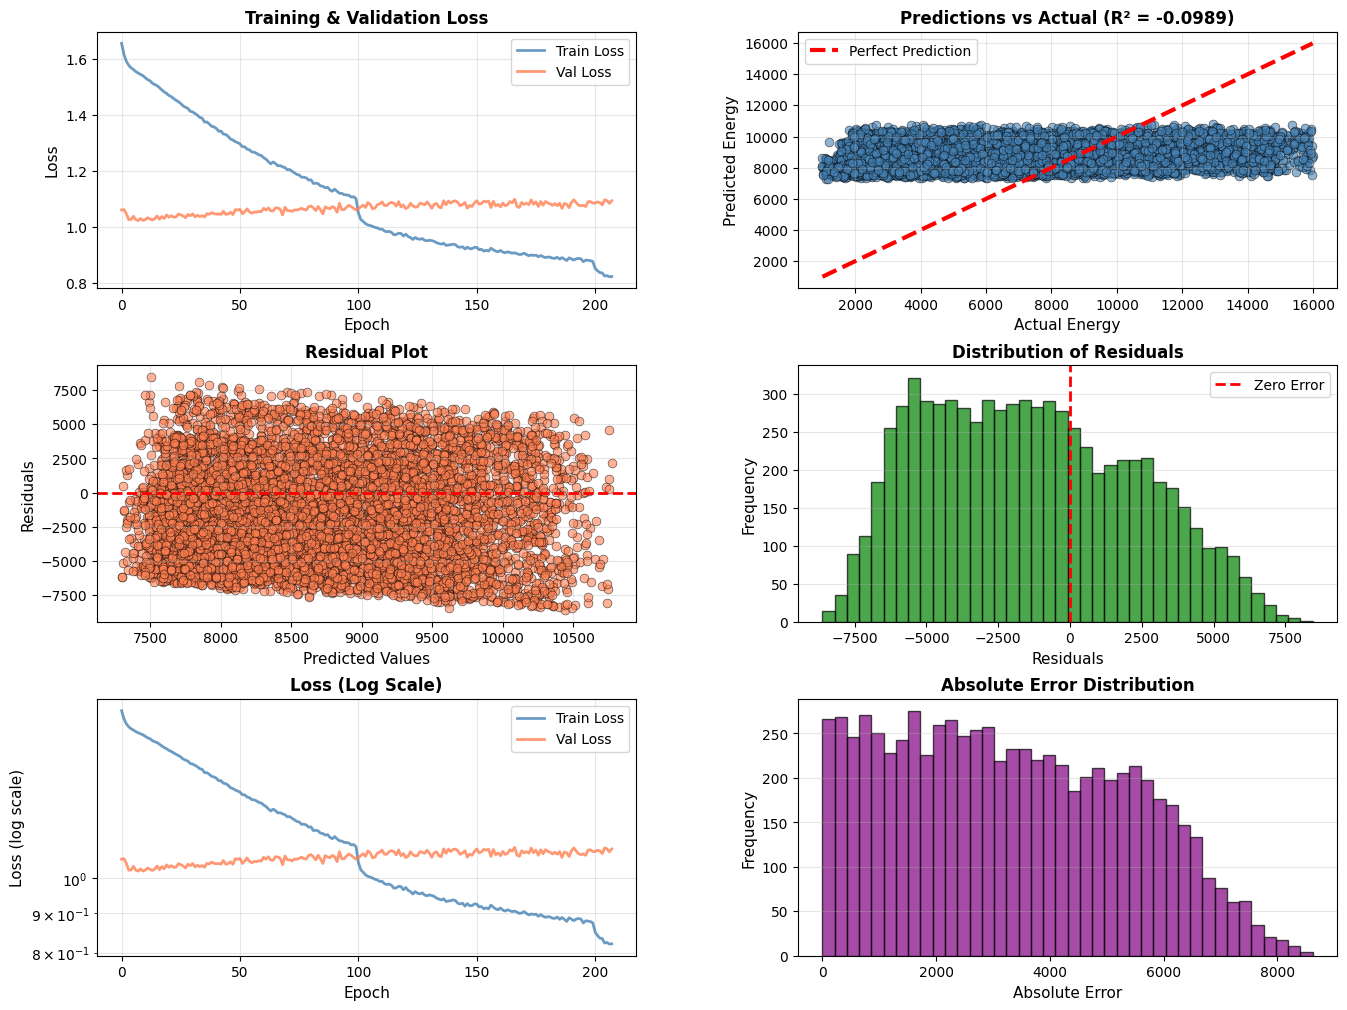


SUMMARY
Model: EBM with Softmax Output
Architecture: 5 hidden layers → Softmax (20 bins) → Energy prediction
Total parameters: 712,340
Epochs trained: 208
Best validation loss: 1.021833
Test R²: -0.0989
Test RMSE: 3870.3617
Test MAE: 3284.7927


In [29]:
# ============================================
# VISUALIZATION
# ============================================

print("\nGenerating plots...")

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Plot 1: Training Loss
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(train_losses, label='Train Loss', linewidth=2, color='steelblue', alpha=0.8)
ax1.plot(val_losses, label='Val Loss', linewidth=2, color='coral', alpha=0.8)
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.set_title('Training & Validation Loss', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Predictions vs Actual
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(y_test_true, y_test_pred, alpha=0.6, s=40, color='steelblue', edgecolors='black', linewidth=0.5)
ax2.plot([y_test_true.min(), y_test_true.max()],
         [y_test_true.min(), y_test_true.max()],
         'r--', lw=3, label='Perfect Prediction')
ax2.set_xlabel('Actual Energy', fontsize=11)
ax2.set_ylabel('Predicted Energy', fontsize=11)
ax2.set_title(f'Predictions vs Actual (R² = {r2:.4f})', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Plot 3: Residuals
ax3 = fig.add_subplot(gs[1, 0])
residuals = y_test_true - y_test_pred
ax3.scatter(y_test_pred, residuals, alpha=0.6, s=40, color='coral', edgecolors='black', linewidth=0.5)
ax3.axhline(y=0, color='r', linestyle='--', lw=2)
ax3.set_xlabel('Predicted Values', fontsize=11)
ax3.set_ylabel('Residuals', fontsize=11)
ax3.set_title('Residual Plot', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Plot 4: Residuals Distribution
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(residuals, bins=40, alpha=0.7, color='green', edgecolor='black')
ax4.axvline(x=0, color='r', linestyle='--', lw=2, label='Zero Error')
ax4.set_xlabel('Residuals', fontsize=11)
ax4.set_ylabel('Frequency', fontsize=11)
ax4.set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')

# Plot 5: Loss Log Scale
ax5 = fig.add_subplot(gs[2, 0])
ax5.semilogy(train_losses, label='Train Loss', linewidth=2, color='steelblue', alpha=0.8)
ax5.semilogy(val_losses, label='Val Loss', linewidth=2, color='coral', alpha=0.8)
ax5.set_xlabel('Epoch', fontsize=11)
ax5.set_ylabel('Loss (log scale)', fontsize=11)
ax5.set_title('Loss (Log Scale)', fontsize=12, fontweight='bold')
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.3, which='both')

# Plot 6: Error Distribution
ax6 = fig.add_subplot(gs[2, 1])
abs_errors = np.abs(residuals)
ax6.hist(abs_errors, bins=40, alpha=0.7, color='purple', edgecolor='black')
ax6.set_xlabel('Absolute Error', fontsize=11)
ax6.set_ylabel('Frequency', fontsize=11)
ax6.set_title('Absolute Error Distribution', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3, axis='y')

plt.savefig('ebm_softmax_results.png', dpi=100, bbox_inches='tight')
print("✓ Plot saved as 'ebm_softmax_results.png'")
plt.show()

print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"Model: EBM with Softmax Output")
print(f"Architecture: 5 hidden layers → Softmax ({num_bins} bins) → Energy prediction")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Epochs trained: {len(train_losses)}")
print(f"Best validation loss: {best_val_loss:.6f}")
print(f"Test R²: {r2:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE: {mae:.4f}")
print("="*80)